# Task 4: Insurance Claim Prediction

**Objective:**  
Predict insurance charges using regression analysis based on customer features such as age, BMI, sex, smoking status, and region.

In [1]:

# Import libraries for data manipulation, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import ML modules for train/test split, regression, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Load Dataset
**Purpose:** Load the insurance dataset and inspect its structure.

In [11]:
# Load insurance dataset from CSV
df = pd.read_csv(r'C:\Users\M.S\Desktop\insurance.csv')

# Display first 5 rows to inspect data
df.head()

# Display info about dataset: data types, non-null counts
df.info()

# Display basic statistics for numerical columns
df.describe()

# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Encode Categorical Features
**Purpose:** Convert categorical variables (sex, smoker, region) to numerical values for modeling.

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

### Split Features and Target
**Purpose:** Separate dataset into input features (X) and target variable (y: insurance charges).

In [14]:
X = df.drop('charges', axis=1)
y = df['charges']

### Train/Test Split
**Purpose:** Split data into training and testing sets for model evaluation.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Model Training
**Purpose:** Train a Linear Regression model to predict insurance charges.

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Model Evaluation
**Purpose:** Evaluate model performance using MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error).

In [17]:
y_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4186.508898366435
RMSE: 5799.587091438356


### Exploratory Data Analysis (EDA)
**Purpose:** Visualize relationships between features and insurance charges.

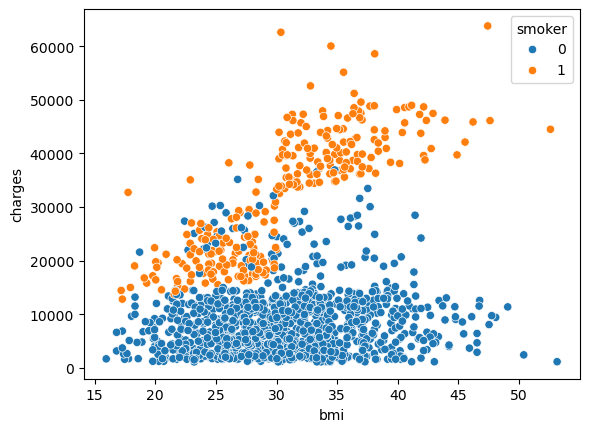

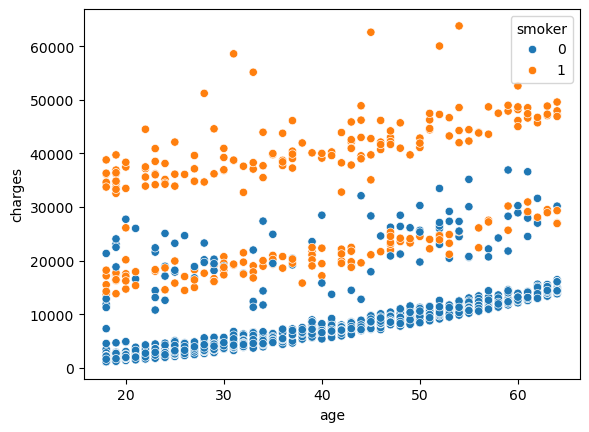

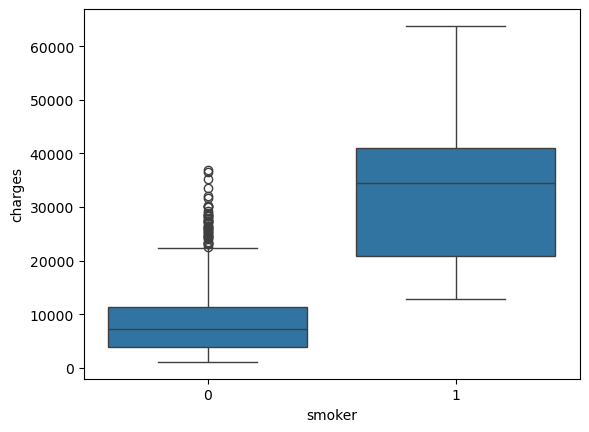

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# BMI vs Charges
sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker')
plt.show()

# Age vs Charges
sns.scatterplot(x='age', y='charges', data=df, hue='smoker')
plt.show()

# Smoker vs Charges (boxplot)
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

### Conclusion
- Linear Regression model provides a basic prediction of insurance charges.  
- Smoking status and BMI appear to have the largest impact on charges.  
- Evaluation metrics (MAE and RMSE) indicate the average prediction error.  
- Visualizations help identify feature relationships and potential outliers.